In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df1=pd.read_csv("automobileEDA.csv")
df1.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


# Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
# highway-mpg vs Price
X=df1[['highway-mpg']]
Y=df1[['price']]

In [6]:
lm=LinearRegression()
lm

LinearRegression()

In [7]:
lm.fit(X,Y)

LinearRegression()

In [8]:
lm.coef_

array([[-821.73337832]])

In [9]:
lm.intercept_

array([38423.30585816])

In [10]:
yhat=lm.predict(X)
yhat[0:5]

array([[16236.50464347],
       [16236.50464347],
       [17058.23802179],
       [13771.3045085 ],
       [20345.17153508]])

In [11]:
# what does fit() does internally-? see notes in register

In [12]:
# engine-size vs price
X=df1[['engine-size']]
Y=df1[['price']]

In [13]:
lm.fit(X,Y)

LinearRegression()

In [14]:
lm.coef_

array([[166.86001569]])

In [15]:
lm.intercept_

array([-7963.33890628])

# Multiple Linear Regression

In [17]:
# MLR is used when it is clear that the dependent varaible is a function of more than one independent variables

In [18]:
z=df1[['horsepower','curb-weight','engine-size','highway-mpg']]
z

,horsepower,curb-weight,engine-size,highway-mpg
0,111.0,2548,130,27
1,111.0,2548,130,27
2,154.0,2823,152,26
3,102.0,2337,109,30
4,115.0,2824,136,22
...,...,...,...,...
196,114.0,2952,141,28
197,160.0,3049,141,25
198,134.0,3012,173,23
199,106.0,3217,145,27


In [19]:
lm.fit(z,df1[['price']])

LinearRegression()

In [20]:
lm.intercept_

array([-15806.62462633])

In [21]:
lm.coef_

array([[53.49574423,  4.70770099, 81.53026382, 36.05748882]])

In [22]:
lm.coef_[0]

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

# Model Evaulation using visualization

In [24]:
import seaborn as sns
%matplotlib inline

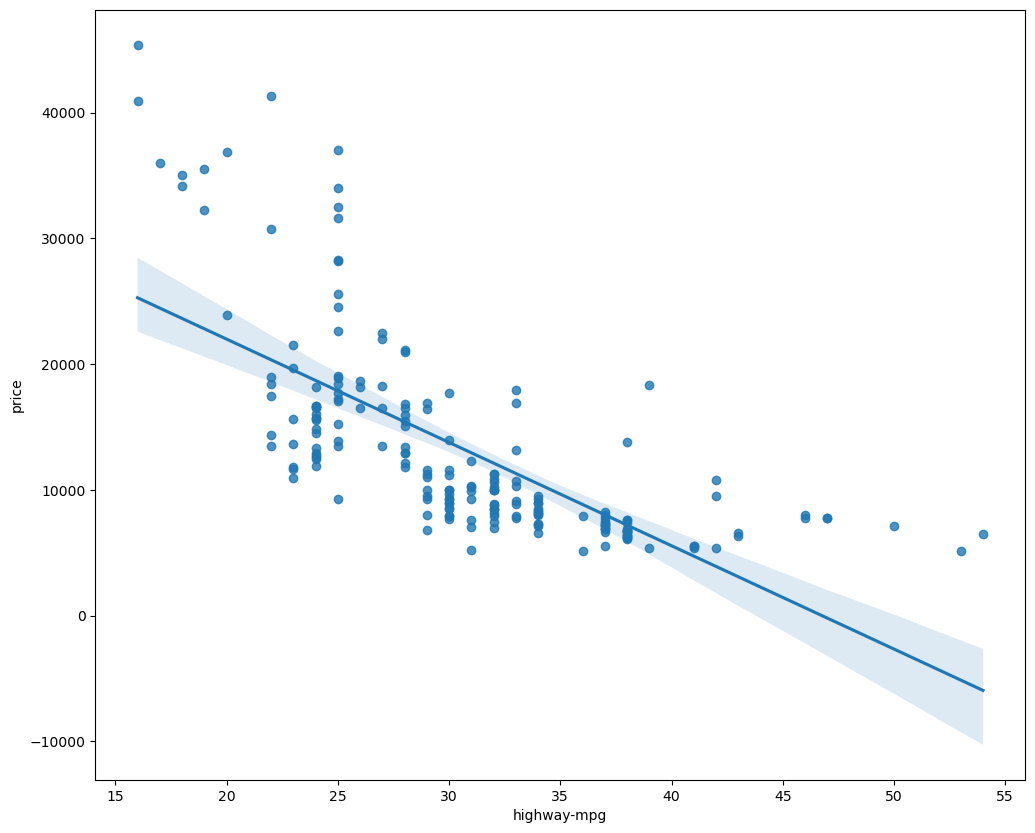

In [25]:
width=12
height=10
plt.figure(figsize=(width,height))
sns.regplot(x="highway-mpg",y="price",data=df1)
plt.show()

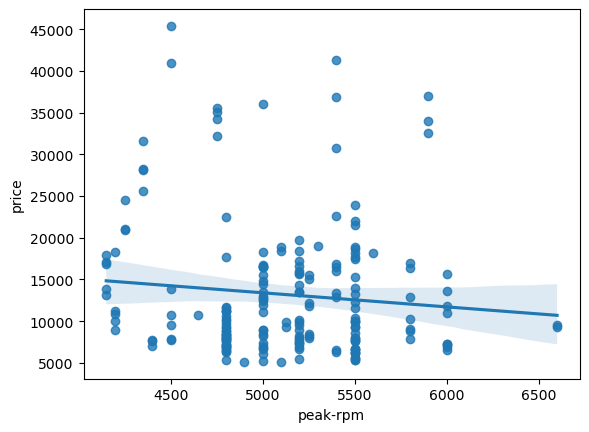

In [26]:
sns.regplot(x='peak-rpm',y='price',data=df1)
plt.show()

In [27]:
df1[['highway-mpg','peak-rpm','price']].corr()

,highway-mpg,peak-rpm,price
highway-mpg,1.000000,-0.058598,-0.704692
peak-rpm,-0.058598,1.000000,-0.101616
price,-0.704692,-0.101616,1.000000


In [28]:
# Residual plot- plot the residuals against the independent variable


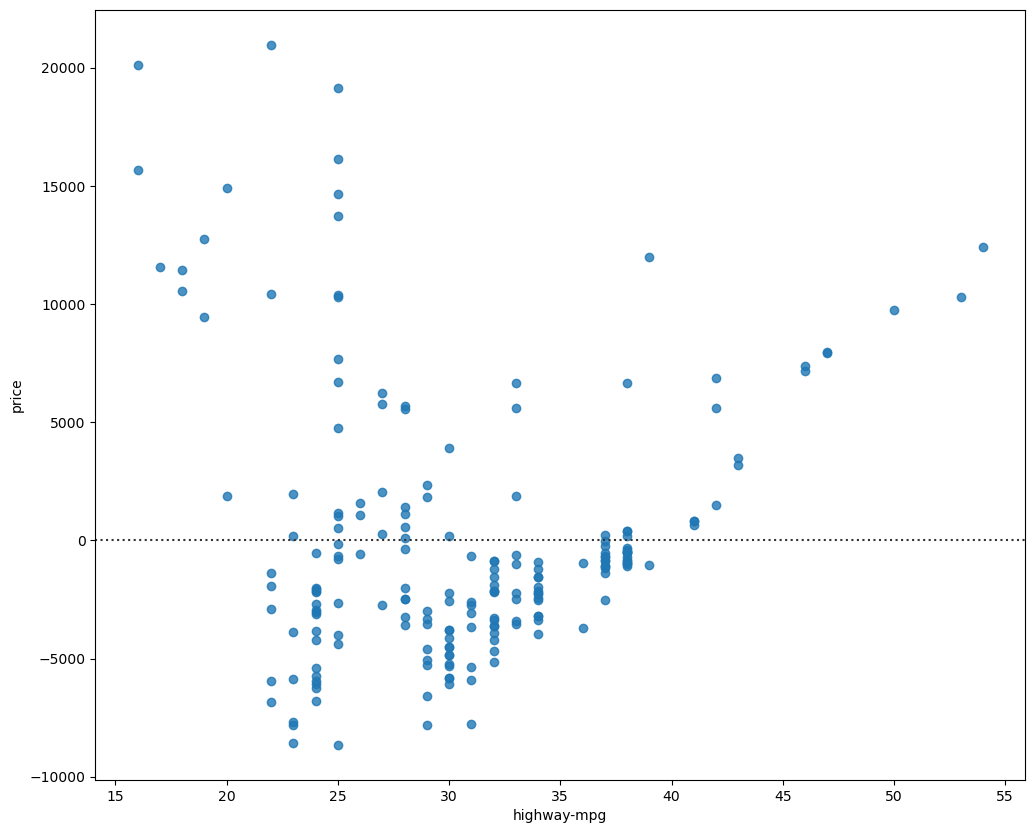

In [29]:
width=12
height=10
plt.figure(figsize=(width,height))
sns.residplot(x=df1['highway-mpg'],y=df1['price'])
plt.show()

In [30]:
yhat=lm.predict(z)
yhat[0:5]

array([[13699.11161184],
       [13699.11161184],
       [19051.65470233],
       [10620.36193015],
       [15521.31420211]])

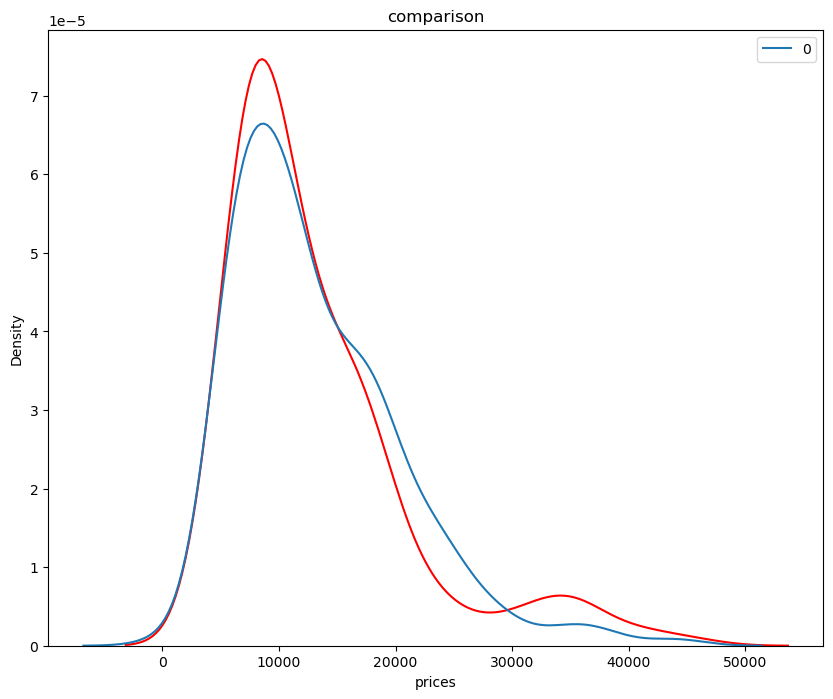

In [31]:
# Distribution plot
width=10
height=8
plt.figure(figsize=(width,height))
ax1=sns.kdeplot(df1['price'],color='r',label='Actual price')
sns.kdeplot(yhat,color='b',label='Predicted price values',ax=ax1)
plt.xlabel('prices')
plt.title('comparison')
plt.show()

# Polynomial regression and pipelines

In [33]:
# higher values of independent variables affecting the dependent variable (price)

In [34]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import  PolynomialFeatures

In [35]:
# scikit learn approach-

In [36]:
x=df1[['highway-mpg']]
y=df1['price']
x

,highway-mpg
0,27
1,27
2,26
3,30
4,22
...,...
196,28
197,25
198,23
199,27


In [37]:
lin_reg=LinearRegression()
lin_reg

LinearRegression()

In [38]:
lin_reg.fit(x,y)

LinearRegression()

In [39]:
lin_reg.coef_

array([-821.73337832])

In [40]:
lin_reg.intercept_

38423.3058581574

In [41]:
poly=PolynomialFeatures(degree=2, include_bias=False)
x_poly=poly.fit_transform(x)
x_poly

array([[  27.,  729.],
       [  27.,  729.],
       [  26.,  676.],
       [  30.,  900.],
       [  22.,  484.],
       [  25.,  625.],
       [  25.,  625.],
       [  25.,  625.],
       [  20.,  400.],
       [  29.,  841.],
       [  29.,  841.],
       [  28.,  784.],
       [  28.,  784.],
       [  25.,  625.],
       [  22.,  484.],
       [  22.,  484.],
       [  20.,  400.],
       [  53., 2809.],
       [  43., 1849.],
       [  43., 1849.],
       [  41., 1681.],
       [  38., 1444.],
       [  30.,  900.],
       [  38., 1444.],
       [  38., 1444.],
       [  38., 1444.],
       [  30.,  900.],
       [  30.,  900.],
       [  24.,  576.],
       [  54., 2916.],
       [  38., 1444.],
       [  42., 1764.],
       [  34., 1156.],
       [  34., 1156.],
       [  34., 1156.],
       [  34., 1156.],
       [  33., 1089.],
       [  33., 1089.],
       [  33., 1089.],
       [  33., 1089.],
       [  28.,  784.],
       [  31.,  961.],
       [  29.,  841.],
       [  2

In [42]:
# Degree 2 means we want to calculate the polynomial regression upto degree of 2, fit understands the structure  of the input x(independent) variable
# and transform generate the higher powers of x upto 2.

In [43]:
poly_reg=LinearRegression()
poly_reg.fit(x_poly,y)

LinearRegression()

In [44]:
poly_reg.intercept_

84193.87777903774

In [45]:
poly_reg.coef_

array([-3773.28654983,    45.35210313])

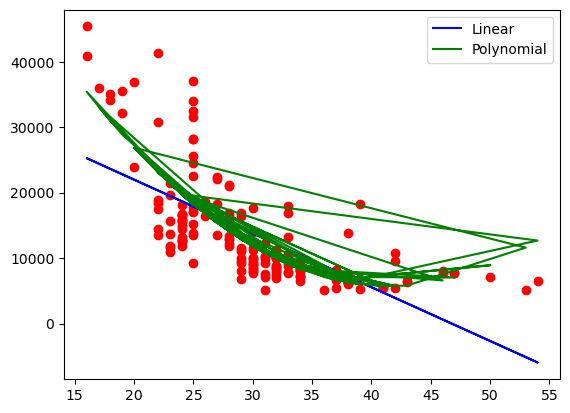

In [46]:
plt.scatter(x,y,color='Red')
plt.plot(x,lin_reg.predict(x),color='blue',label='Linear')
plt.plot(x,poly_reg.predict(x_poly),color='green',label='Polynomial')
plt.legend()
plt.show()

In [47]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

In [48]:
x = df1['highway-mpg']
y = df1['price']

In [49]:
# Here we use a polynomial of the 3rd order (cubic) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


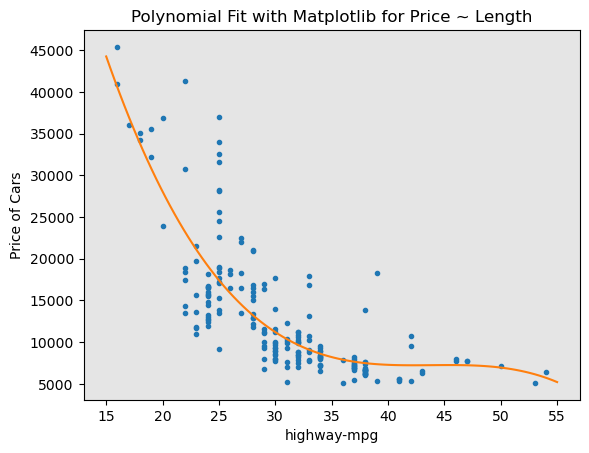

In [50]:
PlotPolly(p, x, y, 'highway-mpg')

In [51]:
np.polyfit(x, y, 3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

In [52]:
# Doing the same for the degree numnered 11

In [53]:
x=df1[['highway-mpg']]

In [54]:
poly=PolynomialFeatures(degree=11,include_bias=False)
x_poly=poly.fit_transform(x)
x_poly

array([[2.70000000e+01, 7.29000000e+02, 1.96830000e+04, ...,
        7.62559748e+12, 2.05891132e+14, 5.55906057e+15],
       [2.70000000e+01, 7.29000000e+02, 1.96830000e+04, ...,
        7.62559748e+12, 2.05891132e+14, 5.55906057e+15],
       [2.60000000e+01, 6.76000000e+02, 1.75760000e+04, ...,
        5.42950368e+12, 1.41167096e+14, 3.67034449e+15],
       ...,
       [2.30000000e+01, 5.29000000e+02, 1.21670000e+04, ...,
        1.80115266e+12, 4.14265112e+13, 9.52809758e+14],
       [2.70000000e+01, 7.29000000e+02, 1.96830000e+04, ...,
        7.62559748e+12, 2.05891132e+14, 5.55906057e+15],
       [2.50000000e+01, 6.25000000e+02, 1.56250000e+04, ...,
        3.81469727e+12, 9.53674316e+13, 2.38418579e+15]])

In [55]:
poly_reg=LinearRegression()
poly_reg

LinearRegression()

In [56]:
poly_reg.fit(x_poly,y)

LinearRegression()

In [57]:
poly_reg.intercept_

78903.99623645212

In [58]:
poly_reg.coef_

array([-1.78823621e-05, -2.37332320e-03, -7.00543543e-03, -7.52632736e-02,
       -4.39429628e-01,  6.05108492e-02, -3.50626933e-03,  1.09085249e-04,
       -1.91298733e-06,  1.78714687e-08, -6.93430296e-11])

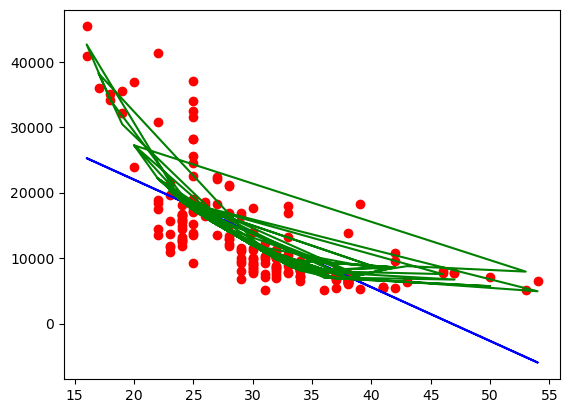

In [59]:
plt.scatter(x,y,color='Red')
plt.plot(x,lin_reg.predict(x),color='Blue',label='Linear Regression')
plt.plot(x,poly_reg.predict(x_poly),color='Green',label='Polynomial Regression')
plt.show()
plt.close()

In [60]:
x=df1[['highway-mpg']]
y=df1['price']

In [61]:
poly=PolynomialFeatures(degree=4,include_bias=False)
x_poly=poly.fit_transform(x)
x_poly

array([[2.700000e+01, 7.290000e+02, 1.968300e+04, 5.314410e+05],
       [2.700000e+01, 7.290000e+02, 1.968300e+04, 5.314410e+05],
       [2.600000e+01, 6.760000e+02, 1.757600e+04, 4.569760e+05],
       [3.000000e+01, 9.000000e+02, 2.700000e+04, 8.100000e+05],
       [2.200000e+01, 4.840000e+02, 1.064800e+04, 2.342560e+05],
       [2.500000e+01, 6.250000e+02, 1.562500e+04, 3.906250e+05],
       [2.500000e+01, 6.250000e+02, 1.562500e+04, 3.906250e+05],
       [2.500000e+01, 6.250000e+02, 1.562500e+04, 3.906250e+05],
       [2.000000e+01, 4.000000e+02, 8.000000e+03, 1.600000e+05],
       [2.900000e+01, 8.410000e+02, 2.438900e+04, 7.072810e+05],
       [2.900000e+01, 8.410000e+02, 2.438900e+04, 7.072810e+05],
       [2.800000e+01, 7.840000e+02, 2.195200e+04, 6.146560e+05],
       [2.800000e+01, 7.840000e+02, 2.195200e+04, 6.146560e+05],
       [2.500000e+01, 6.250000e+02, 1.562500e+04, 3.906250e+05],
       [2.200000e+01, 4.840000e+02, 1.064800e+04, 2.342560e+05],
       [2.200000e+01, 4.8

In [62]:
poly_reg=LinearRegression()

In [63]:
poly_reg.fit(x_poly,y)

LinearRegression()

In [64]:
poly_reg.intercept_

165673.35737329634

In [65]:
poly_reg.coef_

array([-1.26673852e+04,  3.81976935e+02, -5.17010163e+00,  2.65088385e-02])

In [66]:
from matplotlib import pyplot as plt

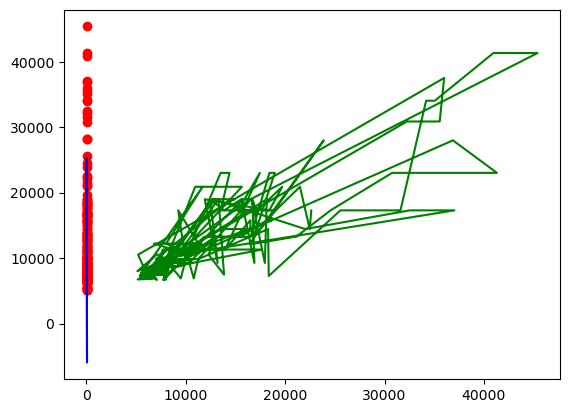

In [67]:
plt.scatter(x,y,color='red')
plt.plot(x,lin_reg.predict(x),color='blue',label='linear regression')
plt.plot(y,poly_reg.predict(x_poly),color='green',label='linear regression')
plt.show()
plt.close()

# Data pipeline

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [70]:
Input=[('scaler',StandardScaler()),('polynomial',PolynomialFeatures(degree=2,include_bias=False)),('linear',LinearRegression())]

In [71]:
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [72]:
pipe.fit(z,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [73]:
ypipe=pipe.predict(z)
ypipe[0:10]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555,
       16136.29619164, 13880.09787302, 15041.58694037, 15457.93465485,
       17974.49032347, 10510.56542385])

In [74]:
pipe.named_steps['linear'].coef_

array([  863.11346309,  1230.37102566,  2914.28541207, -1626.9833804 ,
        2353.71434919, -3593.960683  , -1993.33251552,  -544.42514043,
         201.58916795,  2393.208425  ,  -673.54589352,   153.76427801,
          11.942059  ,   215.37198446])

In [75]:
pipe.named_steps['linear'].intercept_

11649.375342855668

In [76]:
pipe[-1].coef_

array([  863.11346309,  1230.37102566,  2914.28541207, -1626.9833804 ,
        2353.71434919, -3593.960683  , -1993.33251552,  -544.42514043,
         201.58916795,  2393.208425  ,  -673.54589352,   153.76427801,
          11.942059  ,   215.37198446])

In [77]:
pipe[-1].intercept_

11649.375342855668

As there are 4 independent variables involved (highway-mpg,curb-weight,engine-size,horsepower) and degree=2 we will be 
having 15 coefficients in total. In order to see which coefficients belong to which feature-

In [79]:
poly=pipe.named_steps['polynomial']
features=poly.get_feature_names_out(['horsepower','curb-weight','engine-size','highway-mpg'])

In [80]:
coeff=pipe.named_steps['linear'].coef_

In [81]:
for feature,coefficient in zip(features,coeff):
    print(feature,"-",coefficient)

horsepower - 863.1134630852054
curb-weight - 1230.371025664244
engine-size - 2914.285412066939
highway-mpg - -1626.9833804029822
horsepower^2 - 2353.714349194227
horsepower curb-weight - -3593.9606830038847
horsepower engine-size - -1993.3325155154023
horsepower highway-mpg - -544.4251404267785
curb-weight^2 - 201.5891679477473
curb-weight engine-size - 2393.2084249990107
curb-weight highway-mpg - -673.5458935195255
engine-size^2 - 153.76427801168512
engine-size highway-mpg - 11.94205899950569
highway-mpg^2 - 215.37198445678777


# Measures for In-Sample Evaluation

In [83]:
# going for the variable of horsepower-mpg (independent) variable and dependent variable(y) 
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [84]:
df1.columns

Index(['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='object')

In [85]:
# Simple linear Regression

In [86]:
a1=df1[['horsepower']]
b1=df1['price']

In [87]:
lin_model=LinearRegression()

In [88]:
lin_model.fit(a1,b1)

LinearRegression()

In [89]:
ypredicted=lin_model.predict(a1)
ypredicted[0:4]

array([14514.76823442, 14514.76823442, 21918.64247666, 12965.1201372 ])

In [90]:
print("The r2 square value for the a1(independent) and b1(price) dependent variable is:",lin_model.score(a1,b1))

The r2 square value for the a1(independent) and b1(price) dependent variable is: 0.6554109795391572


In [91]:
# Meaning that the 65% variation in dependent variable y is explained by the independent variable x

In [92]:
rsquare=r2_score(b1,ypredicted)
rsquare

0.6554109795391572

In [93]:
# Multiple Linear Regression

In [94]:
Z=df1[['horsepower','curb-weight','engine-size','highway-mpg']]

In [95]:
lin_model1=LinearRegression()

In [96]:
lin_model1.fit(Z,b1)

LinearRegression()

In [97]:
lin_model1.score(Z,b1)

0.8093562806577457

In [98]:
# 80% variation in the y(dependent) variable is explained by the independent variable(Z)

In [99]:
rsquare1=r2_score(b1,lin_model1.predict(Z))
rsquare1

0.8093562806577457

In [100]:
# Polynomial Regression

In [101]:
poly=PolynomialFeatures(degree=3,include_bias=False)
a1_poly=poly.fit_transform(a1)
a1_poly

array([[1.11000000e+02, 1.23210000e+04, 1.36763100e+06],
       [1.11000000e+02, 1.23210000e+04, 1.36763100e+06],
       [1.54000000e+02, 2.37160000e+04, 3.65226400e+06],
       [1.02000000e+02, 1.04040000e+04, 1.06120800e+06],
       [1.15000000e+02, 1.32250000e+04, 1.52087500e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.40000000e+02, 1.96000000e+04, 2.74400000e+06],
       [1.01000000e+02, 1.02010000e+04, 1.03030100e+06],
       [1.01000000e+02, 1.02010000e+04, 1.03030100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [4.80000000e+01, 2.30400

In [102]:
lin_model2=LinearRegression()


In [103]:
lin_model2.fit(a1_poly,b1)

LinearRegression()

In [104]:
lin_model2.score(a1_poly,b1)

0.6627880537087625

In [105]:
rsquare2=r2_score(b1,lin_model2.predict(a1_poly))
rsquare2

0.6627880537087625

In [106]:
# 66% variation in the price is being explained by the independent varibale (considering the higher powers of the same)

# Mean squared-error (MSE)

In [108]:
# Mean Squared Error (MSE) is the average of the squared differences between actual and predicted values.

In [109]:
# Simple linear Regression
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [110]:
a1=df1[['horsepower']]
b1=df1['price']

In [111]:
lin_model1=LinearRegression()

In [112]:
lin_model1.fit(a1,b1)

LinearRegression()

In [113]:
print("The r-squared value for a1 and b1 is:",lin_model1.score(a1,b1))

The r-squared value for a1 and b1 is: 0.6554109795391572


In [114]:
r2_score1=r2_score(b1,lin_model1.predict(a1))
r2_score1

0.6554109795391572

In [115]:
print("The mean squared value is:",mean_squared_error(b1,lin_model1.predict(a1)))

The mean squared value is: 21654544.39825428


In [116]:
# Polynomial Regression

In [117]:
a2=df1[['horsepower','curb-weight','engine-size','highway-mpg']]


In [118]:
from sklearn.preprocessing import PolynomialFeatures

In [119]:
poly_model2=PolynomialFeatures(degree=3,include_bias=False)
a1_poly=poly_model2.fit_transform(a1)
a1_poly

array([[1.11000000e+02, 1.23210000e+04, 1.36763100e+06],
       [1.11000000e+02, 1.23210000e+04, 1.36763100e+06],
       [1.54000000e+02, 2.37160000e+04, 3.65226400e+06],
       [1.02000000e+02, 1.04040000e+04, 1.06120800e+06],
       [1.15000000e+02, 1.32250000e+04, 1.52087500e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.40000000e+02, 1.96000000e+04, 2.74400000e+06],
       [1.01000000e+02, 1.02010000e+04, 1.03030100e+06],
       [1.01000000e+02, 1.02010000e+04, 1.03030100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.21000000e+02, 1.46410000e+04, 1.77156100e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [1.82000000e+02, 3.31240000e+04, 6.02856800e+06],
       [4.80000000e+01, 2.30400

In [120]:
lin_model2=LinearRegression()


In [121]:
lin_model2.fit(a1_poly,b1)

LinearRegression()

In [122]:
print("The r-squared value for the higher degree(3) of a1 and b1:",lin_model2.score(a1_poly,b1))

The r-squared value for the higher degree(3) of a1 and b1: 0.6627880537087625


In [123]:
r2_score2=r2_score(b1,lin_model2.predict(a1_poly))
r2_score2

0.6627880537087625

In [124]:
print("The mean-squared error is:",mean_squared_error(b1,lin_model2.predict(a1_poly)))

The mean-squared error is: 21190956.847144


In [125]:
# Multiple Linear Regression

In [126]:
lin_model3=LinearRegression()

In [127]:
lin_model3.fit(a2,b1)

LinearRegression()

In [128]:
print("The r-squared value for multiple variables a2 and b1 is :",lin_model3.score(a2,b1))

The r-squared value for multiple variables a2 and b1 is : 0.8093562806577457


In [129]:
r2_score3=r2_score(b1,lin_model3.predict(a2))
r2_score3

0.8093562806577457

In [130]:
print("The mean-squared value for the same is:",mean_squared_error(b1,lin_model3.predict(a2)))

The mean-squared value for the same is: 11980366.87072649


# Prediction and Decision Making

In [132]:
# Prediction 

In [133]:
new_input=np.arange(1,100,1).reshape(-1,1)

In [134]:
ypredicted=lin_model1.predict(new_input)


C:\Users\Techjockey\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [135]:
import matplotlib.pyplot as plt
%matplotlib inline

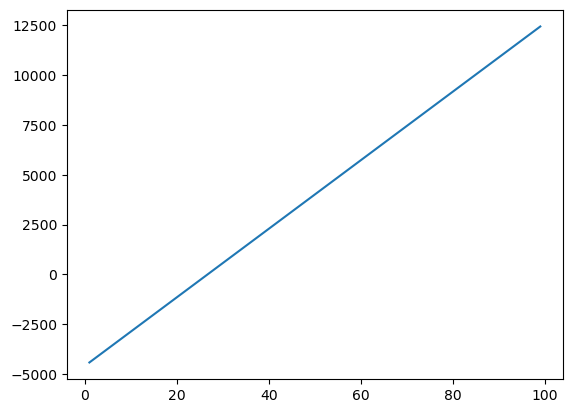

In [136]:
plt.plot(new_input,ypredicted)
plt.show()
plt.close()

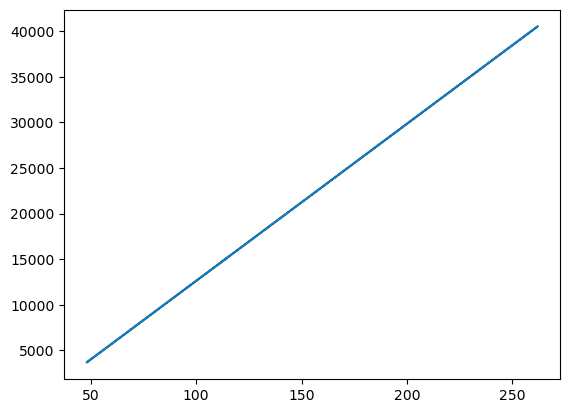

In [137]:
plt.plot(a1,lin_model1.predict(a1))
plt.show()
plt.close()

In [138]:
# Decision Making